In [ ]:
# ============================================================
# 1. Install
# ============================================================
!pip install -q ultralytics

import os
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from ultralytics import YOLO

# ============================================================
# 2. Path setting
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Original LS-SSDD dataset stored in Google Drive
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/SAR_AI_Ship_Detection/LS-SSDD")

# Destination directory for copying the dataset to the Colab local storage
LOCAL_BASE_DIR = Path("/content/LS-SSDD")

# Copy the entire dataset from Google Drive to /content only once
if not LOCAL_BASE_DIR.exists():
    shutil.copytree(DRIVE_BASE_DIR, LOCAL_BASE_DIR)
    print("Copied LS-SSDD to /content")
else:
    print("LS-SSDD already exists in /content")

# Use the faster local (/content) directory from this point onward
BASE_DIR = LOCAL_BASE_DIR

ANN_DIR = BASE_DIR / "Annotations_sub"
TRAIN_IMG_DIR = BASE_DIR / "JPEGImages_sub_train"
TEST_IMG_DIR  = BASE_DIR / "JPEGImages_sub_test"

TRAIN_TXT = BASE_DIR / "train.txt"
VAL_TXT   = BASE_DIR / "val.txt"
TEST_TXT  = BASE_DIR / "test.txt"

OUT_DIR = Path("/content/LS-SSDD-YOLO")

# ============================================================
# 3. Utility functions
# ============================================================
def read_ids(txt_path):
    with open(txt_path, "r") as f:
        return [line.strip() for line in f.readlines() if line.strip()]

def find_image(img_id):
    candidates = []
    for img_dir in [TRAIN_IMG_DIR, TEST_IMG_DIR]:
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
            p = img_dir / f"{img_id}{ext}"
            candidates.append(p)
            if p.exists():
                return p
    return None

def convert_voc_to_yolo(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):
        cls_id = 0  # ship class only

        box = obj.find("bndbox")
        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        # Clip the bounding box coordinates to the image boundaries
        xmin = max(0, min(xmin, w))
        xmax = max(0, min(xmax, w))
        ymin = max(0, min(ymin, h))
        ymax = max(0, min(ymax, h))

        bw = xmax - xmin
        bh = ymax - ymin

        if bw <= 0 or bh <= 0:
            continue

        x_center = (xmin + xmax) / 2 / w
        y_center = (ymin + ymax) / 2 / h
        bw = bw / w
        bh = bh / h

        yolo_lines.append(
            f"{cls_id} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}"
        )

    return yolo_lines

def prepare_split(ids, split_name):
    img_out = OUT_DIR / "images" / split_name
    label_out = OUT_DIR / "labels" / split_name

    img_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    missing_img = 0
    missing_xml = 0

    for img_id in ids:
        img_path = find_image(img_id)
        xml_path = ANN_DIR / f"{img_id}.xml"

        if img_path is None:
            missing_img += 1
            continue

        if not xml_path.exists():
            missing_xml += 1
            continue

        # image copy
        dst_img = img_out / img_path.name
        shutil.copy(img_path, dst_img)

        # label convert
        yolo_lines = convert_voc_to_yolo(xml_path)

        dst_label = label_out / f"{img_path.stem}.txt"
        with open(dst_label, "w") as f:
            f.write("\n".join(yolo_lines))

    print(f"[{split_name}] total ids: {len(ids)}")
    print(f"[{split_name}] missing images: {missing_img}")
    print(f"[{split_name}] missing xml: {missing_xml}")

# ============================================================
# 4. Convert LS-SSDD to YOLO format
# ============================================================
train_ids = read_ids(TRAIN_TXT)
val_ids   = read_ids(VAL_TXT)
test_ids  = read_ids(TEST_TXT)

prepare_split(train_ids, "train")
prepare_split(val_ids, "val")
prepare_split(test_ids, "test")

# ============================================================
# 5. Make data.yaml
# ============================================================
data_yaml = OUT_DIR / "data.yaml"

with open(data_yaml, "w") as f:
    f.write(f"""
path: {OUT_DIR}
train: images/train
val: images/val
test: images/test

names:
  0: ship
""")

print(data_yaml.read_text())

# ============================================================
# 6. Train YOLO
# ============================================================
model = YOLO("yolov8s.pt")  # Load the pretrained YOLOv8s model (YOLOv8n can also be used)

model.train(
    data=str(data_yaml),
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/runs",
    name="ls_ssdd_yolov8s"
)

# ============================================================
# 7. Validation
# ============================================================
metrics = model.val(data=str(data_yaml), split="val")
print(metrics)

# ============================================================
# 8. Test prediction example
# ============================================================
model.predict(
    source=str(OUT_DIR / "images" / "test"),
    imgsz=640,
    conf=0.25,
    save=True
)

# ============================================================
# 9. Save trained YOLO model to Google Drive
# ============================================================

import shutil
from pathlib import Path

# Directory containing the trained model weights
RUN_DIR = Path("/content/runs/ls_ssdd_yolov8s/weights")

# Destination directory for saving the trained models in Google Drive
SAVE_DIR = Path("/content/drive/MyDrive/SAR_AI_Ship_Detection/trained_models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Save the best model
shutil.copy(
    RUN_DIR / "best.pt",
    SAVE_DIR / "ls_ssdd_yolov8s_20epoch_best.pt"
)

# Save the last model
shutil.copy(
    RUN_DIR / "last.pt",
    SAVE_DIR / "ls_ssdd_yolov8s_20epoch_last.pt"
)

print("Saved:")
print(SAVE_DIR / "ls_ssdd_yolov8s_20epoch_best.pt")
print(SAVE_DIR / "ls_ssdd_yolov8s_20epoch_last.pt")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Copied LS-SSDD to /content
[train] total ids: 6000
[train] missing images: 0
[train] missing xml: 0
[val] total ids: 900
[val] missing images: 0
[val] missing xml: 0
[test] total ids: 3000
[test] missing images: 0
[test] missing xml: 0

path: /content/LS-SSDD-YOLO
train: images/train
val: images/val
test: images/test

names:
  0: ship

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=

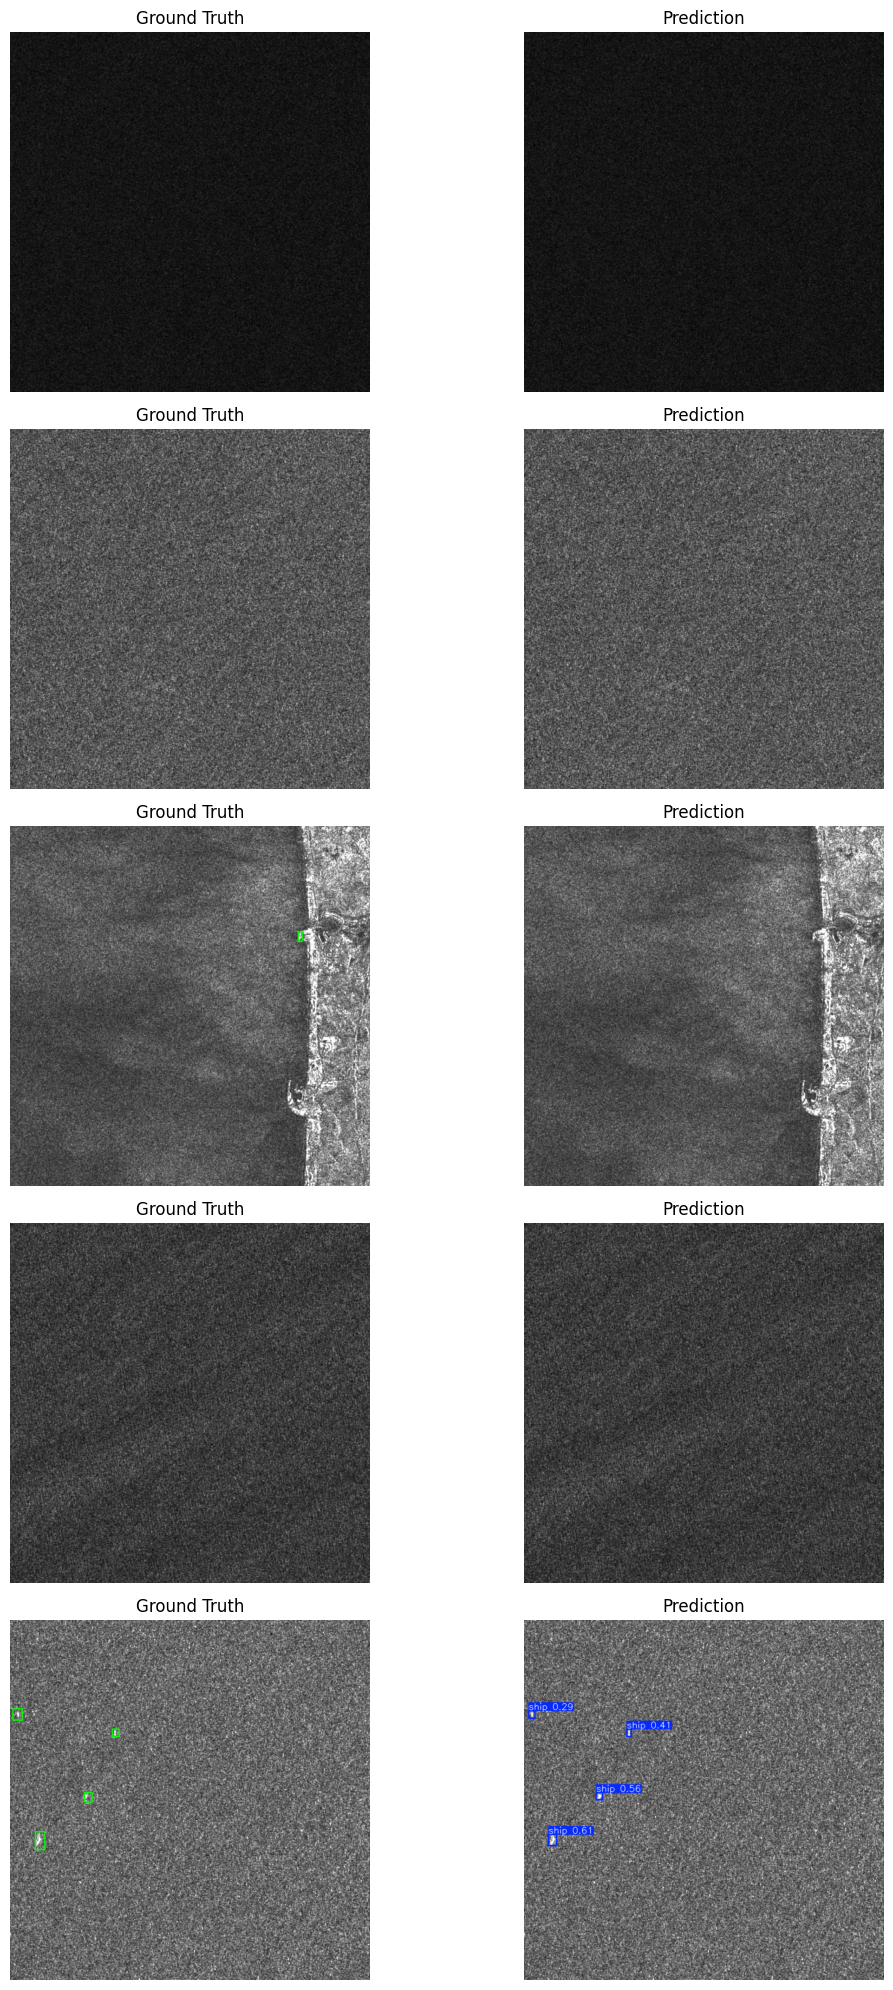

In [ ]:
# ============================================================
# GT vs Prediction
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import random

model = YOLO(
    "/content/drive/MyDrive/SAR_AI_Ship_Detection/trained_models/ls_ssdd_yolov8s_best.pt"
)

IMG_DIR = Path("/content/LS-SSDD-YOLO/images/test")
LABEL_DIR = Path("/content/LS-SSDD-YOLO/labels/test")

sample_images = random.sample(
    list(IMG_DIR.glob("*")),
    5
)

fig, axes = plt.subplots(
    len(sample_images),
    2,
    figsize=(12, 4*len(sample_images))
)

for row, img_path in enumerate(sample_images):

    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Ground Truth
    # --------------------------------------------------------
    gt_img = img_rgb.copy()

    h, w = gt_img.shape[:2]

    label_path = LABEL_DIR / f"{img_path.stem}.txt"

    if label_path.exists():

        with open(label_path) as f:

            for line in f:

                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)

                cv2.rectangle(
                    gt_img,
                    (x1, y1),
                    (x2, y2),
                    (0,255,0),
                    2
                )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------
    pred = model.predict(
        source=str(img_path),
        conf=0.25,
        verbose=False
    )

    pred_img = pred[0].plot()
    pred_img = cv2.cvtColor(
        pred_img,
        cv2.COLOR_BGR2RGB
    )

    axes[row,0].imshow(gt_img)
    axes[row,0].set_title("Ground Truth")
    axes[row,0].axis("off")

    axes[row,1].imshow(pred_img)
    axes[row,1].set_title("Prediction")
    axes[row,1].axis("off")

plt.tight_layout()
plt.show()